In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error,confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Reshape, Add, Embedding
)
import keras_tuner as kt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.layers import AveragePooling1D
from tensorflow.keras.layers import Subtract
from tensorflow.keras.layers import Dot
from tensorflow.keras.layers import Softmax
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.layers import Lambda



df = pd.read_csv("enhanced_dataset.csv")
df.tail()

,date,year,month,day,dayofweek,is_weekend,dayofyear,month_sin,month_cos,dayofyear_sin,...,relative_humidity_2m_max__lag_7,relative_humidity_2m_max__rolling_mean_7d,relative_humidity_2m_max__rolling_std_7d,relative_humidity_2m_max__7day_trend,cloud_rain_interaction,temp_humidity_interaction,precip_cloud_interaction,cloud_volatility_7d,rain_volatility_7d,temp_seasonal_anomaly
9247,2025-04-26,2025,4,26,5,True,116,0.866025,-0.5,0.911169,...,81.0,85.142857,5.843189,9.0,0.0,330.0,0.0,23.027933,15.102065,-2.538462
9248,2025-04-27,2025,4,27,6,True,117,0.866025,-0.5,0.903946,...,91.0,85.714286,6.651172,4.0,330.0,285.6,300.0,23.483530,15.023077,-3.503846
9249,2025-04-28,2025,4,28,0,False,118,0.866025,-0.5,0.896456,...,91.0,85.571429,6.528327,-1.0,288.0,270.6,480.0,23.107410,1.521747,-3.942308
9250,2025-04-29,2025,4,29,1,False,119,0.866025,-0.5,0.888701,...,80.0,87.571429,6.679749,14.0,460.0,329.0,1200.0,22.867111,1.978576,-4.903846
9251,2025-04-30,2025,4,30,2,False,120,0.866025,-0.5,0.880683,...,84.0,89.428571,7.299706,13.0,0.0,524.4,0.0,23.229702,2.003212,-1.792308


In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

class AutoformerTimeSeriesClassifier:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Autoformer-based Time Series Classification model for weather forecasting
        """
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        
        # Autoformer-specific parameters
        self.d_model = 128
        self.num_heads = 8
        self.num_encoder_layers = 4
        self.ff_dim = 512
        self.factor = 5  # Factor for Auto-Correlation
        
        # Decomposition parameters
        self.kernel_size = 25  # Moving average kernel size for decomposition
        
        # Class imbalance thresholds
        self.minority_threshold = 0.08
        self.balanced_threshold = 0.20
        
    def series_decomposition(self, x, layer_idx=0):
        """
        Series decomposition layer using Keras operations - separates trend and seasonal components
        """
        # Use Conv1D with average pooling for moving average trend extraction
        trend = AveragePooling1D(
            pool_size=self.kernel_size, 
            strides=1, 
            padding='same',
            name=f'trend_pool_layer{layer_idx}'
        )(x)
        
        # Seasonal component = original - trend
        seasonal = Subtract(name=f'seasonal_subtract_layer{layer_idx}')([x, trend])
        
        return seasonal, trend
    
    def auto_correlation_layer(self, queries, keys, values, layer_idx=0, head_idx=0):
        """
        Auto-Correlation mechanism using Keras layers only
        """
        # Simplified auto-correlation using attention-like mechanism
        # Get dimension from the model parameter instead of dynamic shape
        d_k = tf.constant(float(self.d_model // self.num_heads), dtype=tf.float32)
        
        # Scale queries
        scaled_queries = Lambda(lambda x: x / tf.sqrt(d_k), name=f'scale_queries_l{layer_idx}_h{head_idx}')(queries)
        
        # Compute attention scores (simplified version of auto-correlation)
        scores = Dot(axes=[2, 2], name=f'dot_scores_l{layer_idx}_h{head_idx}')([scaled_queries, keys])
        attention_weights = Softmax(axis=-1, name=f'softmax_l{layer_idx}_h{head_idx}')(scores)
        
        # Apply attention to values
        output = Dot(axes=[2, 1], name=f'dot_output_l{layer_idx}_h{head_idx}')([attention_weights, values])
        
        return output
    
    def autoformer_encoder_layer(self, x, layer_idx=0):
        """
        Single Autoformer encoder layer with Auto-Correlation and decomposition using Keras layers
        """
        # Series decomposition with unique naming
        seasonal_init, trend_init = self.series_decomposition(x, layer_idx=layer_idx)
        
        # Multi-head Auto-Correlation for seasonal component
        seasonal_multi_head = []
        head_dim = self.d_model // self.num_heads
        
        for i in range(self.num_heads):
            # Linear projections for queries, keys, values with globally unique names
            q = Dense(head_dim, use_bias=False, name=f'q_l{layer_idx}_h{i}')(seasonal_init)
            k = Dense(head_dim, use_bias=False, name=f'k_l{layer_idx}_h{i}')(seasonal_init)  
            v = Dense(head_dim, use_bias=False, name=f'v_l{layer_idx}_h{i}')(seasonal_init)
            
            # Apply simplified auto-correlation (attention-like)
            head_output = self.auto_correlation_layer(q, k, v, layer_idx=layer_idx, head_idx=i)
            seasonal_multi_head.append(head_output)
        
        # Concatenate heads
        if len(seasonal_multi_head) > 1:
            seasonal_attended = Concatenate(axis=-1, name=f'concat_l{layer_idx}')(seasonal_multi_head)
        else:
            seasonal_attended = seasonal_multi_head[0]
            
        seasonal_attended = Dense(self.d_model, name=f'dense_seasonal_l{layer_idx}')(seasonal_attended)
        seasonal_attended = Dropout(0.1, name=f'dropout1_l{layer_idx}')(seasonal_attended)
        
        # Residual connection for seasonal
        seasonal_output = Add(name=f'add1_l{layer_idx}')([seasonal_init, seasonal_attended])
        seasonal_output = LayerNormalization(name=f'ln1_l{layer_idx}')(seasonal_output)
        
        # Feed-forward network for seasonal
        seasonal_ff = Dense(self.ff_dim, activation='gelu', name=f'ff1_l{layer_idx}')(seasonal_output)
        seasonal_ff = Dropout(0.1, name=f'dropout2_l{layer_idx}')(seasonal_ff)
        seasonal_ff = Dense(self.d_model, name=f'ff2_l{layer_idx}')(seasonal_ff)
        seasonal_ff = Dropout(0.1, name=f'dropout3_l{layer_idx}')(seasonal_ff)
        
        # Second residual connection
        seasonal_final = Add(name=f'add2_l{layer_idx}')([seasonal_output, seasonal_ff])
        seasonal_final = LayerNormalization(name=f'ln2_l{layer_idx}')(seasonal_final)
        
        # Simple processing for trend
        trend_processed = Dense(self.d_model, activation='linear', name=f'trend_l{layer_idx}')(trend_init)
        
        # Combine seasonal and trend
        output = Add(name=f'add_final_l{layer_idx}')([seasonal_final, trend_processed])
        
        return output
    
    # Decoder removed - not needed for classification
    
    def build_autoformer_model(self, input_shape, num_classes):
        """
        Build the Autoformer Encoder-Only architecture for classification
        """
        print(f"Building Autoformer Encoder-Only model with input shape: {input_shape}")
        
        # Input
        inputs = Input(shape=input_shape)
        
        # Input embedding
        embedded = Dense(self.d_model, activation='linear')(inputs)
        embedded = Dropout(0.1)(embedded)
        
        # Add positional encoding
        pos_encoding = self.positional_encoding(self.sequence_length, self.d_model)
        x = embedded + pos_encoding
        
        # Autoformer Encoder Stack Only (no decoder needed for classification)
        for i in range(self.num_encoder_layers):
            x = self.autoformer_encoder_layer(x, layer_idx=i)
        
        # Global average pooling for sequence representation
        pooled_output = GlobalAveragePooling1D()(x)
        
        # Classification head with progressive dimension reduction
        x = Dense(512, activation='gelu', kernel_regularizer=l2(0.001))(pooled_output)
        x = Dropout(0.3)(x)
        
        x = Dense(256, activation='gelu', kernel_regularizer=l2(0.001))(x)
        x = Dropout(0.2)(x)
        
        x = Dense(128, activation='gelu')(x)
        x = Dropout(0.1)(x)
        
        # Output layer for multi-step classification
        outputs = Dense(self.forecast_horizon * num_classes, activation='softmax')(x)
        outputs = Reshape((self.forecast_horizon, num_classes))(outputs)
        
        model = Model(inputs=inputs, outputs=outputs)
        return model
    
    def positional_encoding(self, length, depth):
        """Positional encoding for transformer"""
        depth = depth / 2
        positions = np.arange(length)[:, np.newaxis]
        depths = np.arange(depth)[np.newaxis, :] / depth
        
        angle_rads = positions * (1 / (10000**depths))
        
        pos_encoding = np.concatenate([
            np.sin(angle_rads),
            np.cos(angle_rads)
        ], axis=-1)
        
        return tf.cast(pos_encoding, dtype=tf.float32)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        """Focal loss for handling class imbalance"""
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            ce = -y_true * K.log(y_pred)
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        return focal_loss_fn
    
    def preprocess_data(self, target_col='weather_condition'):
        """Enhanced preprocessing (same as original)"""
        print("🧹 Enhanced preprocessing for Autoformer...")
        df = self.df.copy()
        
        # Handle missing values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != target_col:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        df = df.dropna(subset=[target_col])
        
        # Merge weather classes
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Class distribution:\n{class_counts}")
        
        # Categorize classes
        self.minority_classes = []
        self.balanced_classes = []
        self.majority_classes = []
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"Minority classes: {self.minority_classes}")
        print(f"Balanced classes: {self.balanced_classes}")
        print(f"Majority classes: {self.majority_classes}")
        
        # Encode target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded']]
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        
        return df
    
    def create_improved_sliding_windows(self):
        """Same improved sliding window strategy as original"""
        print(f"\n🪟 Creating improved sliding windows for Autoformer...")
        
        X, y = [], []
        data = self.df
        features = data[self.feature_cols].values
        target = data[self.target_col].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        for i in range(len(target)):
            if target[i] in minority_class_ids:
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_seq = target[start_idx + self.sequence_length:end_idx]
                        
                        if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y.append(y_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            if any(cls_id in balanced_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            if all(cls_id in majority_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                majority_windows += 1
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Window creation results:")
        print(f"Minority: {minority_windows}, Balanced: {balanced_windows}, Majority: {majority_windows}")
        print(f"Total windows: {len(X)}")
        
        return X, y
    
    def train_autoformer_model(self, use_augmentation=True):
        """Train the Autoformer model"""
        print("\n" + "="*70)
        print("TRAINING AUTOFORMER ENCODER-ONLY CLASSIFICATION MODEL")
        print("="*70)
        
        # Create sliding windows
        X, y = self.create_improved_sliding_windows()
        
        # Add augmentation if needed
        if use_augmentation:
            X, y = self.add_targeted_augmentation(X, y, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"Training data: X={X.shape}, y={y.shape}")
        print(f"Number of classes: {num_classes}")
        
        # Convert to categorical
        y_onehot = to_categorical(y, num_classes=num_classes)
        
        # Train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build and compile Autoformer model
        self.model = self.build_autoformer_model((self.sequence_length, X.shape[2]), num_classes)
        
        print("\nAutoformer Encoder-Only Model Architecture:")
        self.model.summary()
        
        # Compile with focal loss
        self.model.compile(
            optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),
            loss=self.focal_loss(alpha=0.25, gamma=2.0),
            metrics=['accuracy']
        )
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print("\nTraining Autoformer model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=16,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print("\nEvaluating Autoformer model...")
        y_pred_prob = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=-1)
        y_true = np.argmax(y_test, axis=-1)
        
        return self.evaluate_results(y_true, y_pred, history)
    
    def add_targeted_augmentation(self, X, y, augment_factor=1):
        """Targeted augmentation for minority classes"""
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_aug = list(y)
        augmented_count = 0
        
        for i in range(len(X)):
            if any(cls_id in minority_class_ids for cls_id in y[i]):
                for _ in range(augment_factor):
                    noise_scale = 0.01
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    X_aug.append(X_noisy)
                    y_aug.append(y[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_aug)
    
    def evaluate_results(self, y_true, y_pred, history):
        """Comprehensive evaluation with confusion matrix and detailed analysis"""
        print("\n" + "="*70)
        print("AUTOFORMER TIME SERIES CLASSIFICATION RESULTS")
        print("="*70)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
        print(f"Overall Test Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} accuracy: {day_acc:.4f}")
        
        # Classification report for Day 1
        print(f"\nDetailed Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(
            y_true[:, 0], y_pred[:, 0], 
            target_names=target_names, 
            zero_division=0,
            output_dict=True
        )
        print(classification_report(
            y_true[:, 0], y_pred[:, 0], 
            target_names=target_names, 
            zero_division=0
        ))
        
        # Confusion Matrix for Day 1
        print(f"\nConfusion Matrix (Day 1):")
        print("-" * 70)
        cm = confusion_matrix(y_true[:, 0], y_pred[:, 0], labels=range(len(target_names)))
        
        # Display confusion matrix with labels
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 10))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
        disp.plot(cmap='Blues', xticks_rotation=45)
        plt.title('Confusion Matrix - Day 1 Weather Predictions', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
        
        # Class-tier performance analysis (same as original LSTM approach)
        print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
        
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
            
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:25s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
        
        # Problem class identification
        print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] < 0.2:
                struggling_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
        
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
        
        # Success stories
        print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        # Autoformer-specific analysis
        print(f"\n🤖 AUTOFORMER ENCODER-ONLY ANALYSIS:")
        print("-" * 50)
        print(f"  Auto-Correlation Factor: {self.factor}")
        print(f"  Decomposition Kernel Size: {self.kernel_size}")
        print(f"  Encoder Layers: {self.num_encoder_layers}")
        print(f"  Model Dimension: {self.d_model}")
        print(f"  Total Parameters: {self.model.count_params():,}")
        print(f"  🎯 Architecture: Encoder-Only (No Decoder)")
        print(f"  📊 Design: Optimized for Classification Tasks")
        
        return overall_acc, daily_accuracies, history, y_true, y_pred
    
    def predict_next_week(self, recent_data):
        """Enhanced prediction with Autoformer"""
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        pred_prob = self.model.predict(input_seq, verbose=0)
        pred_classes = np.argmax(pred_prob[0], axis=-1)
        
        predicted_conditions = self.label_encoder.inverse_transform(pred_classes)
        confidence_scores = np.max(pred_prob[0], axis=-1)
        
        # Calculate prediction uncertainty
        entropy = -np.sum(pred_prob[0] * np.log(pred_prob[0] + 1e-8), axis=-1)
        normalized_entropy = entropy / np.log(len(self.label_encoder.classes_))
        
        return predicted_conditions, confidence_scores, normalized_entropy


🌤️  TIME SERIES TRANSFORMER + REBALANCING Weather Forecasting
🧹 Enhanced preprocessing for Autoformer...
Class distribution:
weather_condition
Cloudy ☁️             3403
Partly Clear 🌤/⛅      1998
Light Drizzle 🌦       1347
Clear Sky ☀️          1251
Moderate Drizzle 🌧     522
Light Rain 🌦           330
Moderate Rain 🌧        218
Heavy Drizzle 🌧        170
Heavy Rain 🌧            13
Name: count, dtype: int64
Minority classes: ['Moderate Drizzle 🌧', 'Light Rain 🌦', 'Moderate Rain 🌧', 'Heavy Drizzle 🌧', 'Heavy Rain 🌧']
Balanced classes: ['Light Drizzle 🌦', 'Clear Sky ☀️']
Majority classes: ['Cloudy ☁️', 'Partly Clear 🌤/⛅']

TRAINING AUTOFORMER ENCODER-ONLY CLASSIFICATION MODEL

🪟 Creating improved sliding windows for Autoformer...
Window creation results:
Minority: 8762, Balanced: 2678, Majority: 835
Total windows: 12275
Added 6792 augmented sequences for minority classes
Training data: X=(19067, 10, 148), y=(19067, 3)
Number of classes: 9
Training samples: 15253, Test samples: 3814
Buil

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 10, 148)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10, 128)   │     19,072 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 10, 128)   │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 10, 128)   │          0 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend_pool_layer0   │ (None, 10, 128)   │          0 │ add_3[0][0]       │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seasonal_subtract_… │ (None, 10, 128)   │          0 │ add_3[0][0],      │
│ (Subtract)          │                   │            │ trend_pool_layer… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h0 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h1 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h2 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h3 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h4 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h5 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h6 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h7 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h0 │ (None, 10, 16)    │          0 │ q_l0_h0[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_l0_h0 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h1 │ (None, 10, 16)    │          0 │ q_l0_h1[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_l0_h1 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h2 │ (None, 10, 16)    │          0 │ q_l0_h2[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_l0_h2 (Dense)     │ (None, 10, 16)    │      2,048 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h3 │ (None, 10, 16)    │          0 │ q_l0_h3[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,110,427 (4.24 MB)

 Trainable params: 1,110,427 (4.24 MB)

 Non-trainable params: 0 (0.00 B)


Training Autoformer model...
Epoch 1/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 104s 52ms/step - accuracy: 0.2280 - loss: 1.1805 - val_accuracy: 0.2691 - val_loss: 0.9663 - learning_rate: 1.0000e-04
Epoch 2/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.2623 - loss: 0.9362 - val_accuracy: 0.2823 - val_loss: 0.8317 - learning_rate: 1.0000e-04
Epoch 3/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.2716 - loss: 0.8152 - val_accuracy: 0.3027 - val_loss: 0.7459 - learning_rate: 1.0000e-04
Epoch 4/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.2997 - loss: 0.7427 - val_accuracy: 0.3425 - val_loss: 0.6823 - learning_rate: 1.0000e-04
Epoch 5/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.3319 - loss: 0.6895 - val_accuracy: 0.3882 - val_loss: 0.6366 - learning_rate: 1.0000e-04
Epoch 6/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.3587 - loss: 0.6516 - val_accuracy: 0.3983 - val_loss: 0.6056 - learning_rate: 1.0000e-04
Epoch 7/200
763

<Figure size 1200x1000 with 0 Axes>

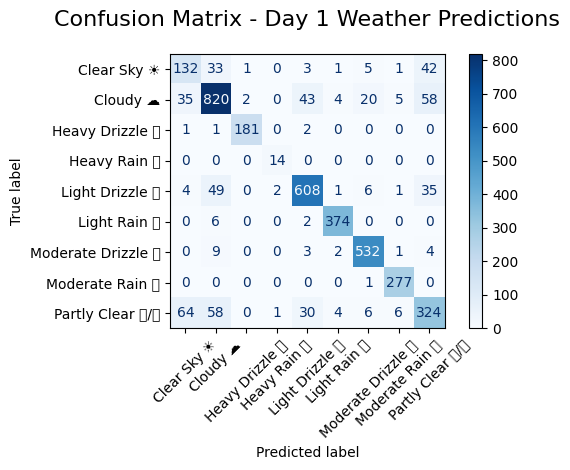


🎯 CLASS-TIER PERFORMANCE ANALYSIS:

MINORITY CLASSES:
----------------------------------------
  ✅ Moderate Drizzle 🌧       : P=0.933, R=0.966, F1=0.949, N=551.0
  ✅ Light Rain 🌦             : P=0.969, R=0.979, F1=0.974, N=382.0
  ✅ Moderate Rain 🌧          : P=0.952, R=0.996, F1=0.974, N=278.0
  ✅ Heavy Drizzle 🌧          : P=0.984, R=0.978, F1=0.981, N=185.0
  ✅ Heavy Rain 🌧             : P=0.824, R=1.000, F1=0.903, N=14.0

  📊 MINORITY AVERAGES:
     Precision: 0.9323
     Recall: 0.9839
     F1-Score: 0.9562

BALANCED CLASSES:
----------------------------------------
  ✅ Light Drizzle 🌦          : P=0.880, R=0.861, F1=0.870, N=706.0
  ✅ Clear Sky ☀️             : P=0.559, R=0.606, F1=0.581, N=218.0

  📊 BALANCED AVERAGES:
     Precision: 0.7196
     Recall: 0.7333
     F1-Score: 0.7260

MAJORITY CLASSES:
----------------------------------------
  ✅ Cloudy ☁️                : P=0.840, R=0.831, F1=0.835, N=987.0
  ✅ Partly Clear 🌤/⛅         : P=0.700, R=0.657, F1=0.678, N=493.0

  📊

In [12]:
def run_transformer_weather_forecasting(df, use_augmentation=True):
    """Run Time Series Transformer + rebalancing weather forecasting"""
    print("🌤️  TIME SERIES TRANSFORMER + REBALANCING Weather Forecasting")
    print("=" * 70)
    
    # Initialize Transformer model
    model = AutoformerTimeSeriesClassifier(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train Transformer model with rebalancing
    acc, daily_accs, history, y_true, y_pred = model.train_autoformer_model()
    
    print(f"\n🎯 FINAL TRANSFORMER RESULTS:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Best Day Accuracy: {max(daily_accs):.4f}")
    
    return model, acc, daily_accs, y_true, y_pred, history

# Usage:
transformer_model, acc, daily_accs, y_true, y_pred, history = run_transformer_weather_forecasting(df)

**Change the model dimension to 256 instead of 128**

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

class AutoformerTimeSeriesClassifier:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Autoformer-based Time Series Classification model for weather forecasting
        """
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        
        # Autoformer-specific parameters
        self.d_model = 256
        self.num_heads = 8
        self.num_encoder_layers = 4
        self.ff_dim = 512
        self.factor = 5  # Factor for Auto-Correlation
        
        # Decomposition parameters
        self.kernel_size = 25  # Moving average kernel size for decomposition
        
        # Class imbalance thresholds
        self.minority_threshold = 0.08
        self.balanced_threshold = 0.20
        
    def series_decomposition(self, x, layer_idx=0):
        """
        Series decomposition layer using Keras operations - separates trend and seasonal components
        """
        # Use Conv1D with average pooling for moving average trend extraction
        trend = AveragePooling1D(
            pool_size=self.kernel_size, 
            strides=1, 
            padding='same',
            name=f'trend_pool_layer{layer_idx}'
        )(x)
        
        # Seasonal component = original - trend
        seasonal = Subtract(name=f'seasonal_subtract_layer{layer_idx}')([x, trend])
        
        return seasonal, trend
    
    def auto_correlation_layer(self, queries, keys, values, layer_idx=0, head_idx=0):
        """
        Auto-Correlation mechanism using Keras layers only
        """
        # Simplified auto-correlation using attention-like mechanism
        # Get dimension from the model parameter instead of dynamic shape
        d_k = tf.constant(float(self.d_model // self.num_heads), dtype=tf.float32)
        
        # Scale queries
        scaled_queries = Lambda(lambda x: x / tf.sqrt(d_k), name=f'scale_queries_l{layer_idx}_h{head_idx}')(queries)
        
        # Compute attention scores (simplified version of auto-correlation)
        scores = Dot(axes=[2, 2], name=f'dot_scores_l{layer_idx}_h{head_idx}')([scaled_queries, keys])
        attention_weights = Softmax(axis=-1, name=f'softmax_l{layer_idx}_h{head_idx}')(scores)
        
        # Apply attention to values
        output = Dot(axes=[2, 1], name=f'dot_output_l{layer_idx}_h{head_idx}')([attention_weights, values])
        
        return output
    
    def autoformer_encoder_layer(self, x, layer_idx=0):
        """
        Single Autoformer encoder layer with Auto-Correlation and decomposition using Keras layers
        """
        # Series decomposition with unique naming
        seasonal_init, trend_init = self.series_decomposition(x, layer_idx=layer_idx)
        
        # Multi-head Auto-Correlation for seasonal component
        seasonal_multi_head = []
        head_dim = self.d_model // self.num_heads
        
        for i in range(self.num_heads):
            # Linear projections for queries, keys, values with globally unique names
            q = Dense(head_dim, use_bias=False, name=f'q_l{layer_idx}_h{i}')(seasonal_init)
            k = Dense(head_dim, use_bias=False, name=f'k_l{layer_idx}_h{i}')(seasonal_init)  
            v = Dense(head_dim, use_bias=False, name=f'v_l{layer_idx}_h{i}')(seasonal_init)
            
            # Apply simplified auto-correlation (attention-like)
            head_output = self.auto_correlation_layer(q, k, v, layer_idx=layer_idx, head_idx=i)
            seasonal_multi_head.append(head_output)
        
        # Concatenate heads
        if len(seasonal_multi_head) > 1:
            seasonal_attended = Concatenate(axis=-1, name=f'concat_l{layer_idx}')(seasonal_multi_head)
        else:
            seasonal_attended = seasonal_multi_head[0]
            
        seasonal_attended = Dense(self.d_model, name=f'dense_seasonal_l{layer_idx}')(seasonal_attended)
        seasonal_attended = Dropout(0.1, name=f'dropout1_l{layer_idx}')(seasonal_attended)
        
        # Residual connection for seasonal
        seasonal_output = Add(name=f'add1_l{layer_idx}')([seasonal_init, seasonal_attended])
        seasonal_output = LayerNormalization(name=f'ln1_l{layer_idx}')(seasonal_output)
        
        # Feed-forward network for seasonal
        seasonal_ff = Dense(self.ff_dim, activation='gelu', name=f'ff1_l{layer_idx}')(seasonal_output)
        seasonal_ff = Dropout(0.1, name=f'dropout2_l{layer_idx}')(seasonal_ff)
        seasonal_ff = Dense(self.d_model, name=f'ff2_l{layer_idx}')(seasonal_ff)
        seasonal_ff = Dropout(0.1, name=f'dropout3_l{layer_idx}')(seasonal_ff)
        
        # Second residual connection
        seasonal_final = Add(name=f'add2_l{layer_idx}')([seasonal_output, seasonal_ff])
        seasonal_final = LayerNormalization(name=f'ln2_l{layer_idx}')(seasonal_final)
        
        # Simple processing for trend
        trend_processed = Dense(self.d_model, activation='linear', name=f'trend_l{layer_idx}')(trend_init)
        
        # Combine seasonal and trend
        output = Add(name=f'add_final_l{layer_idx}')([seasonal_final, trend_processed])
        
        return output
    
    # Decoder removed - not needed for classification
    
    def build_autoformer_model(self, input_shape, num_classes):
        """
        Build the Autoformer Encoder-Only architecture for classification
        """
        print(f"Building Autoformer Encoder-Only model with input shape: {input_shape}")
        
        # Input
        inputs = Input(shape=input_shape)
        
        # Input embedding
        embedded = Dense(self.d_model, activation='linear')(inputs)
        embedded = Dropout(0.1)(embedded)
        
        # Add positional encoding
        pos_encoding = self.positional_encoding(self.sequence_length, self.d_model)
        x = embedded + pos_encoding
        
        # Autoformer Encoder Stack Only (no decoder needed for classification)
        for i in range(self.num_encoder_layers):
            x = self.autoformer_encoder_layer(x, layer_idx=i)
        
        # Global average pooling for sequence representation
        pooled_output = GlobalAveragePooling1D()(x)
        
        # Classification head with progressive dimension reduction
        x = Dense(512, activation='gelu', kernel_regularizer=l2(0.001))(pooled_output)
        x = Dropout(0.3)(x)
        
        x = Dense(256, activation='gelu', kernel_regularizer=l2(0.001))(x)
        x = Dropout(0.2)(x)
        
        x = Dense(128, activation='gelu')(x)
        x = Dropout(0.1)(x)
        
        # Output layer for multi-step classification
        outputs = Dense(self.forecast_horizon * num_classes, activation='softmax')(x)
        outputs = Reshape((self.forecast_horizon, num_classes))(outputs)
        
        model = Model(inputs=inputs, outputs=outputs)
        return model
    
    def positional_encoding(self, length, depth):
        """Positional encoding for transformer"""
        depth = depth / 2
        positions = np.arange(length)[:, np.newaxis]
        depths = np.arange(depth)[np.newaxis, :] / depth
        
        angle_rads = positions * (1 / (10000**depths))
        
        pos_encoding = np.concatenate([
            np.sin(angle_rads),
            np.cos(angle_rads)
        ], axis=-1)
        
        return tf.cast(pos_encoding, dtype=tf.float32)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        """Focal loss for handling class imbalance"""
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            ce = -y_true * K.log(y_pred)
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        return focal_loss_fn
    
    def preprocess_data(self, target_col='weather_condition'):
        """Enhanced preprocessing (same as original)"""
        print("🧹 Enhanced preprocessing for Autoformer...")
        df = self.df.copy()
        
        # Handle missing values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != target_col:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        df = df.dropna(subset=[target_col])
        
        # Merge weather classes
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Class distribution:\n{class_counts}")
        
        # Categorize classes
        self.minority_classes = []
        self.balanced_classes = []
        self.majority_classes = []
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"Minority classes: {self.minority_classes}")
        print(f"Balanced classes: {self.balanced_classes}")
        print(f"Majority classes: {self.majority_classes}")
        
        # Encode target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded']]
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        
        return df
    
    def create_improved_sliding_windows(self):
        """Same improved sliding window strategy as original"""
        print(f"\n🪟 Creating improved sliding windows for Autoformer...")
        
        X, y = [], []
        data = self.df
        features = data[self.feature_cols].values
        target = data[self.target_col].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        for i in range(len(target)):
            if target[i] in minority_class_ids:
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_seq = target[start_idx + self.sequence_length:end_idx]
                        
                        if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y.append(y_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            if any(cls_id in balanced_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            if all(cls_id in majority_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                majority_windows += 1
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Window creation results:")
        print(f"Minority: {minority_windows}, Balanced: {balanced_windows}, Majority: {majority_windows}")
        print(f"Total windows: {len(X)}")
        
        return X, y
    
    def train_autoformer_model(self, use_augmentation=True):
        """Train the Autoformer model"""
        print("\n" + "="*70)
        print("TRAINING AUTOFORMER ENCODER-ONLY CLASSIFICATION MODEL")
        print("="*70)
        
        # Create sliding windows
        X, y = self.create_improved_sliding_windows()
        
        # Add augmentation if needed
        if use_augmentation:
            X, y = self.add_targeted_augmentation(X, y, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"Training data: X={X.shape}, y={y.shape}")
        print(f"Number of classes: {num_classes}")
        
        # Convert to categorical
        y_onehot = to_categorical(y, num_classes=num_classes)
        
        # Train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build and compile Autoformer model
        self.model = self.build_autoformer_model((self.sequence_length, X.shape[2]), num_classes)
        
        print("\nAutoformer Encoder-Only Model Architecture:")
        self.model.summary()
        
        # Compile with focal loss
        self.model.compile(
            optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),
            loss=self.focal_loss(alpha=0.25, gamma=2.0),
            metrics=['accuracy']
        )
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print("\nTraining Autoformer model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=16,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print("\nEvaluating Autoformer model...")
        y_pred_prob = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=-1)
        y_true = np.argmax(y_test, axis=-1)
        
        return self.evaluate_results(y_true, y_pred, history)
    
    def add_targeted_augmentation(self, X, y, augment_factor=1):
        """Targeted augmentation for minority classes"""
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_aug = list(y)
        augmented_count = 0
        
        for i in range(len(X)):
            if any(cls_id in minority_class_ids for cls_id in y[i]):
                for _ in range(augment_factor):
                    noise_scale = 0.01
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    X_aug.append(X_noisy)
                    y_aug.append(y[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_aug)
    
    def evaluate_results(self, y_true, y_pred, history):
        """Comprehensive evaluation with confusion matrix and detailed analysis"""
        print("\n" + "="*70)
        print("AUTOFORMER TIME SERIES CLASSIFICATION RESULTS")
        print("="*70)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
        print(f"Overall Test Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} accuracy: {day_acc:.4f}")
        
        # Classification report for Day 1
        print(f"\nDetailed Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(
            y_true[:, 0], y_pred[:, 0], 
            target_names=target_names, 
            zero_division=0,
            output_dict=True
        )
        print(classification_report(
            y_true[:, 0], y_pred[:, 0], 
            target_names=target_names, 
            zero_division=0
        ))
        
        # Confusion Matrix for Day 1
        print(f"\nConfusion Matrix (Day 1):")
        print("-" * 70)
        cm = confusion_matrix(y_true[:, 0], y_pred[:, 0], labels=range(len(target_names)))
        
        # Display confusion matrix with labels
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 10))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
        disp.plot(cmap='Blues', xticks_rotation=45)
        plt.title('Confusion Matrix - Day 1 Weather Predictions', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
        
        # Class-tier performance analysis (same as original LSTM approach)
        print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
        
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
            
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:25s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
        
        # Problem class identification
        print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] < 0.2:
                struggling_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
        
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
        
        # Success stories
        print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        # Autoformer-specific analysis
        print(f"\n🤖 AUTOFORMER ENCODER-ONLY ANALYSIS:")
        print("-" * 50)
        print(f"  Auto-Correlation Factor: {self.factor}")
        print(f"  Decomposition Kernel Size: {self.kernel_size}")
        print(f"  Encoder Layers: {self.num_encoder_layers}")
        print(f"  Model Dimension: {self.d_model}")
        print(f"  Total Parameters: {self.model.count_params():,}")
        print(f"  🎯 Architecture: Encoder-Only (No Decoder)")
        print(f"  📊 Design: Optimized for Classification Tasks")
        
        return overall_acc, daily_accuracies, history, y_true, y_pred
    
    def predict_next_week(self, recent_data):
        """Enhanced prediction with Autoformer"""
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        pred_prob = self.model.predict(input_seq, verbose=0)
        pred_classes = np.argmax(pred_prob[0], axis=-1)
        
        predicted_conditions = self.label_encoder.inverse_transform(pred_classes)
        confidence_scores = np.max(pred_prob[0], axis=-1)
        
        # Calculate prediction uncertainty
        entropy = -np.sum(pred_prob[0] * np.log(pred_prob[0] + 1e-8), axis=-1)
        normalized_entropy = entropy / np.log(len(self.label_encoder.classes_))
        
        return predicted_conditions, confidence_scores, normalized_entropy


🌤️  TIME SERIES TRANSFORMER + REBALANCING Weather Forecasting
🧹 Enhanced preprocessing for Autoformer...
Class distribution:
weather_condition
Cloudy ☁️             3403
Partly Clear 🌤/⛅      1998
Light Drizzle 🌦       1347
Clear Sky ☀️          1251
Moderate Drizzle 🌧     522
Light Rain 🌦           330
Moderate Rain 🌧        218
Heavy Drizzle 🌧        170
Heavy Rain 🌧            13
Name: count, dtype: int64
Minority classes: ['Moderate Drizzle 🌧', 'Light Rain 🌦', 'Moderate Rain 🌧', 'Heavy Drizzle 🌧', 'Heavy Rain 🌧']
Balanced classes: ['Light Drizzle 🌦', 'Clear Sky ☀️']
Majority classes: ['Cloudy ☁️', 'Partly Clear 🌤/⛅']

TRAINING AUTOFORMER ENCODER-ONLY CLASSIFICATION MODEL

🪟 Creating improved sliding windows for Autoformer...
Window creation results:
Minority: 8762, Balanced: 2678, Majority: 835
Total windows: 12275
Added 6792 augmented sequences for minority classes
Training data: X=(19067, 10, 148), y=(19067, 3)
Number of classes: 9
Training samples: 15253, Test samples: 3814
Buil

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 10, 148)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 10, 256)   │     38,144 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 10, 256)   │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 10, 256)   │          0 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend_pool_layer0   │ (None, 10, 256)   │          0 │ add_4[0][0]       │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seasonal_subtract_… │ (None, 10, 256)   │          0 │ add_4[0][0],      │
│ (Subtract)          │                   │            │ trend_pool_layer… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h0 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h1 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h2 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h3 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h4 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h5 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h6 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h7 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h0 │ (None, 10, 32)    │          0 │ q_l0_h0[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_l0_h0 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h1 │ (None, 10, 32)    │          0 │ q_l0_h1[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_l0_h1 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h2 │ (None, 10, 32)    │          0 │ q_l0_h2[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_l0_h2 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h3 │ (None, 10, 32)    │          0 │ q_l0_h3[0][0]     │
│ (Lambda)            │                   │            │                 

 Total params: 2,705,947 (10.32 MB)

 Trainable params: 2,705,947 (10.32 MB)

 Non-trainable params: 0 (0.00 B)


Training Autoformer model...
Epoch 1/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 106s 62ms/step - accuracy: 0.2293 - loss: 1.3159 - val_accuracy: 0.2803 - val_loss: 1.0676 - learning_rate: 1.0000e-04
Epoch 2/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 48s 62ms/step - accuracy: 0.2649 - loss: 1.0270 - val_accuracy: 0.2963 - val_loss: 0.8833 - learning_rate: 1.0000e-04
Epoch 3/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 48s 63ms/step - accuracy: 0.2899 - loss: 0.8621 - val_accuracy: 0.3686 - val_loss: 0.7497 - learning_rate: 1.0000e-04
Epoch 4/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - accuracy: 0.3476 - loss: 0.7465 - val_accuracy: 0.4144 - val_loss: 0.6557 - learning_rate: 1.0000e-04
Epoch 5/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 49s 65ms/step - accuracy: 0.3964 - loss: 0.6684 - val_accuracy: 0.4464 - val_loss: 0.5970 - learning_rate: 1.0000e-04
Epoch 6/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.4375 - loss: 0.6072 - val_accuracy: 0.4649 - val_loss: 0.5521 - learning_rate: 1.0000e-04
Epoch 7/200
763

<Figure size 1200x1000 with 0 Axes>

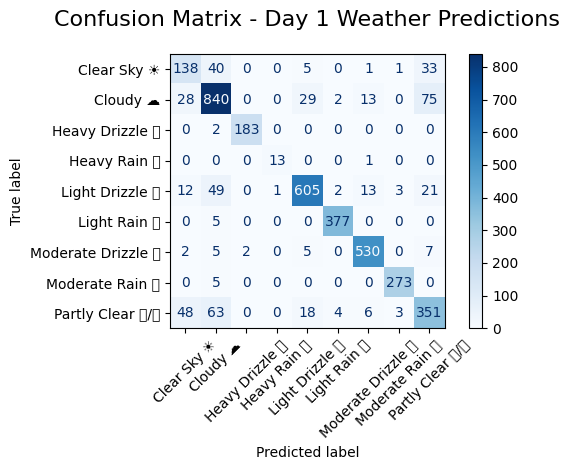


🎯 CLASS-TIER PERFORMANCE ANALYSIS:

MINORITY CLASSES:
----------------------------------------
  ✅ Moderate Drizzle 🌧       : P=0.940, R=0.962, F1=0.951, N=551.0
  ✅ Light Rain 🌦             : P=0.979, R=0.987, F1=0.983, N=382.0
  ✅ Moderate Rain 🌧          : P=0.975, R=0.982, F1=0.978, N=278.0
  ✅ Heavy Drizzle 🌧          : P=0.989, R=0.989, F1=0.989, N=185.0
  ✅ Heavy Rain 🌧             : P=0.929, R=0.929, F1=0.929, N=14.0

  📊 MINORITY AVERAGES:
     Precision: 0.9623
     Recall: 0.9697
     F1-Score: 0.9660

BALANCED CLASSES:
----------------------------------------
  ✅ Light Drizzle 🌦          : P=0.914, R=0.857, F1=0.885, N=706.0
  ✅ Clear Sky ☀️             : P=0.605, R=0.633, F1=0.619, N=218.0

  📊 BALANCED AVERAGES:
     Precision: 0.7596
     Recall: 0.7450
     F1-Score: 0.7517

MAJORITY CLASSES:
----------------------------------------
  ✅ Cloudy ☁️                : P=0.833, R=0.851, F1=0.842, N=987.0
  ✅ Partly Clear 🌤/⛅         : P=0.721, R=0.712, F1=0.716, N=493.0

  📊

In [14]:
def run_transformer_weather_forecasting(df, use_augmentation=True):
    """Run Time Series Transformer + rebalancing weather forecasting"""
    print("🌤️  TIME SERIES TRANSFORMER + REBALANCING Weather Forecasting")
    print("=" * 70)
    
    # Initialize Transformer model
    model = AutoformerTimeSeriesClassifier(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train Transformer model with rebalancing
    acc, daily_accs, history, y_true, y_pred = model.train_autoformer_model()
    
    print(f"\n🎯 FINAL TRANSFORMER RESULTS:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Best Day Accuracy: {max(daily_accs):.4f}")
    
    return model, acc, daily_accs, y_true, y_pred, history

# Usage:
transformer_model, acc, daily_accs, y_true, y_pred, history = run_transformer_weather_forecasting(df)

**Try 3: d_model = 256 instead of 128 and number layers  = 6 instead of 4**

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

class AutoformerTimeSeriesClassifier:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        """
        Autoformer-based Time Series Classification model for weather forecasting
        """
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        
        # Autoformer-specific parameters
        self.d_model = 256
        self.num_heads = 8
        self.num_encoder_layers = 6
        self.ff_dim = 512
        self.factor = 5  # Factor for Auto-Correlation
        
        # Decomposition parameters
        self.kernel_size = 25  # Moving average kernel size for decomposition
        
        # Class imbalance thresholds
        self.minority_threshold = 0.08
        self.balanced_threshold = 0.20
        
    def series_decomposition(self, x, layer_idx=0):
        """
        Series decomposition layer using Keras operations - separates trend and seasonal components
        """
        # Use Conv1D with average pooling for moving average trend extraction
        trend = AveragePooling1D(
            pool_size=self.kernel_size, 
            strides=1, 
            padding='same',
            name=f'trend_pool_layer{layer_idx}'
        )(x)
        
        # Seasonal component = original - trend
        seasonal = Subtract(name=f'seasonal_subtract_layer{layer_idx}')([x, trend])
        
        return seasonal, trend
    
    def auto_correlation_layer(self, queries, keys, values, layer_idx=0, head_idx=0):
        """
        Auto-Correlation mechanism using Keras layers only
        """
        # Simplified auto-correlation using attention-like mechanism
        # Get dimension from the model parameter instead of dynamic shape
        d_k = tf.constant(float(self.d_model // self.num_heads), dtype=tf.float32)
        
        # Scale queries
        scaled_queries = Lambda(lambda x: x / tf.sqrt(d_k), name=f'scale_queries_l{layer_idx}_h{head_idx}')(queries)
        
        # Compute attention scores (simplified version of auto-correlation)
        scores = Dot(axes=[2, 2], name=f'dot_scores_l{layer_idx}_h{head_idx}')([scaled_queries, keys])
        attention_weights = Softmax(axis=-1, name=f'softmax_l{layer_idx}_h{head_idx}')(scores)
        
        # Apply attention to values
        output = Dot(axes=[2, 1], name=f'dot_output_l{layer_idx}_h{head_idx}')([attention_weights, values])
        
        return output
    
    def autoformer_encoder_layer(self, x, layer_idx=0):
        """
        Single Autoformer encoder layer with Auto-Correlation and decomposition using Keras layers
        """
        # Series decomposition with unique naming
        seasonal_init, trend_init = self.series_decomposition(x, layer_idx=layer_idx)
        
        # Multi-head Auto-Correlation for seasonal component
        seasonal_multi_head = []
        head_dim = self.d_model // self.num_heads
        
        for i in range(self.num_heads):
            # Linear projections for queries, keys, values with globally unique names
            q = Dense(head_dim, use_bias=False, name=f'q_l{layer_idx}_h{i}')(seasonal_init)
            k = Dense(head_dim, use_bias=False, name=f'k_l{layer_idx}_h{i}')(seasonal_init)  
            v = Dense(head_dim, use_bias=False, name=f'v_l{layer_idx}_h{i}')(seasonal_init)
            
            # Apply simplified auto-correlation (attention-like)
            head_output = self.auto_correlation_layer(q, k, v, layer_idx=layer_idx, head_idx=i)
            seasonal_multi_head.append(head_output)
        
        # Concatenate heads
        if len(seasonal_multi_head) > 1:
            seasonal_attended = Concatenate(axis=-1, name=f'concat_l{layer_idx}')(seasonal_multi_head)
        else:
            seasonal_attended = seasonal_multi_head[0]
            
        seasonal_attended = Dense(self.d_model, name=f'dense_seasonal_l{layer_idx}')(seasonal_attended)
        seasonal_attended = Dropout(0.1, name=f'dropout1_l{layer_idx}')(seasonal_attended)
        
        # Residual connection for seasonal
        seasonal_output = Add(name=f'add1_l{layer_idx}')([seasonal_init, seasonal_attended])
        seasonal_output = LayerNormalization(name=f'ln1_l{layer_idx}')(seasonal_output)
        
        # Feed-forward network for seasonal
        seasonal_ff = Dense(self.ff_dim, activation='gelu', name=f'ff1_l{layer_idx}')(seasonal_output)
        seasonal_ff = Dropout(0.1, name=f'dropout2_l{layer_idx}')(seasonal_ff)
        seasonal_ff = Dense(self.d_model, name=f'ff2_l{layer_idx}')(seasonal_ff)
        seasonal_ff = Dropout(0.1, name=f'dropout3_l{layer_idx}')(seasonal_ff)
        
        # Second residual connection
        seasonal_final = Add(name=f'add2_l{layer_idx}')([seasonal_output, seasonal_ff])
        seasonal_final = LayerNormalization(name=f'ln2_l{layer_idx}')(seasonal_final)
        
        # Simple processing for trend
        trend_processed = Dense(self.d_model, activation='linear', name=f'trend_l{layer_idx}')(trend_init)
        
        # Combine seasonal and trend
        output = Add(name=f'add_final_l{layer_idx}')([seasonal_final, trend_processed])
        
        return output
    
    # Decoder removed - not needed for classification
    
    def build_autoformer_model(self, input_shape, num_classes):
        """
        Build the Autoformer Encoder-Only architecture for classification
        """
        print(f"Building Autoformer Encoder-Only model with input shape: {input_shape}")
        
        # Input
        inputs = Input(shape=input_shape)
        
        # Input embedding
        embedded = Dense(self.d_model, activation='linear')(inputs)
        embedded = Dropout(0.1)(embedded)
        
        # Add positional encoding
        pos_encoding = self.positional_encoding(self.sequence_length, self.d_model)
        x = embedded + pos_encoding
        
        # Autoformer Encoder Stack Only (no decoder needed for classification)
        for i in range(self.num_encoder_layers):
            x = self.autoformer_encoder_layer(x, layer_idx=i)
        
        # Global average pooling for sequence representation
        pooled_output = GlobalAveragePooling1D()(x)
        
        # Classification head with progressive dimension reduction
        x = Dense(512, activation='gelu', kernel_regularizer=l2(0.001))(pooled_output)
        x = Dropout(0.3)(x)
        
        x = Dense(256, activation='gelu', kernel_regularizer=l2(0.001))(x)
        x = Dropout(0.2)(x)
        
        x = Dense(128, activation='gelu')(x)
        x = Dropout(0.1)(x)
        
        # Output layer for multi-step classification
        outputs = Dense(self.forecast_horizon * num_classes, activation='softmax')(x)
        outputs = Reshape((self.forecast_horizon, num_classes))(outputs)
        
        model = Model(inputs=inputs, outputs=outputs)
        return model
    
    def positional_encoding(self, length, depth):
        """Positional encoding for transformer"""
        depth = depth / 2
        positions = np.arange(length)[:, np.newaxis]
        depths = np.arange(depth)[np.newaxis, :] / depth
        
        angle_rads = positions * (1 / (10000**depths))
        
        pos_encoding = np.concatenate([
            np.sin(angle_rads),
            np.cos(angle_rads)
        ], axis=-1)
        
        return tf.cast(pos_encoding, dtype=tf.float32)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        """Focal loss for handling class imbalance"""
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            ce = -y_true * K.log(y_pred)
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        return focal_loss_fn
    
    def preprocess_data(self, target_col='weather_condition'):
        """Enhanced preprocessing (same as original)"""
        print("🧹 Enhanced preprocessing for Autoformer...")
        df = self.df.copy()
        
        # Handle missing values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != target_col:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        df = df.dropna(subset=[target_col])
        
        # Merge weather classes
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Class distribution:\n{class_counts}")
        
        # Categorize classes
        self.minority_classes = []
        self.balanced_classes = []
        self.majority_classes = []
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"Minority classes: {self.minority_classes}")
        print(f"Balanced classes: {self.balanced_classes}")
        print(f"Majority classes: {self.majority_classes}")
        
        # Encode target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded']]
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        
        return df
    
    def create_improved_sliding_windows(self):
        """Same improved sliding window strategy as original"""
        print(f"\n🪟 Creating improved sliding windows for Autoformer...")
        
        X, y = [], []
        data = self.df
        features = data[self.feature_cols].values
        target = data[self.target_col].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        for i in range(len(target)):
            if target[i] in minority_class_ids:
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_seq = target[start_idx + self.sequence_length:end_idx]
                        
                        if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y.append(y_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            if any(cls_id in balanced_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            if all(cls_id in majority_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                majority_windows += 1
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Window creation results:")
        print(f"Minority: {minority_windows}, Balanced: {balanced_windows}, Majority: {majority_windows}")
        print(f"Total windows: {len(X)}")
        
        return X, y
    
    def train_autoformer_model(self, use_augmentation=True):
        """Train the Autoformer model"""
        print("\n" + "="*70)
        print("TRAINING AUTOFORMER ENCODER-ONLY CLASSIFICATION MODEL")
        print("="*70)
        
        # Create sliding windows
        X, y = self.create_improved_sliding_windows()
        
        # Add augmentation if needed
        if use_augmentation:
            X, y = self.add_targeted_augmentation(X, y, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"Training data: X={X.shape}, y={y.shape}")
        print(f"Number of classes: {num_classes}")
        
        # Convert to categorical
        y_onehot = to_categorical(y, num_classes=num_classes)
        
        # Train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build and compile Autoformer model
        self.model = self.build_autoformer_model((self.sequence_length, X.shape[2]), num_classes)
        
        print("\nAutoformer Encoder-Only Model Architecture:")
        self.model.summary()
        
        # Compile with focal loss
        self.model.compile(
            optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),
            loss=self.focal_loss(alpha=0.25, gamma=2.0),
            metrics=['accuracy']
        )
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print("\nTraining Autoformer model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=16,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print("\nEvaluating Autoformer model...")
        y_pred_prob = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=-1)
        y_true = np.argmax(y_test, axis=-1)
        
        return self.evaluate_results(y_true, y_pred, history)
    
    def add_targeted_augmentation(self, X, y, augment_factor=1):
        """Targeted augmentation for minority classes"""
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_aug = list(y)
        augmented_count = 0
        
        for i in range(len(X)):
            if any(cls_id in minority_class_ids for cls_id in y[i]):
                for _ in range(augment_factor):
                    noise_scale = 0.01
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    X_aug.append(X_noisy)
                    y_aug.append(y[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_aug)
    
    def evaluate_results(self, y_true, y_pred, history):
        """Comprehensive evaluation with confusion matrix and detailed analysis"""
        print("\n" + "="*70)
        print("AUTOFORMER TIME SERIES CLASSIFICATION RESULTS")
        print("="*70)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
        print(f"Overall Test Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} accuracy: {day_acc:.4f}")
        
        # Classification report for Day 1
        print(f"\nDetailed Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(
            y_true[:, 0], y_pred[:, 0], 
            target_names=target_names, 
            zero_division=0,
            output_dict=True
        )
        print(classification_report(
            y_true[:, 0], y_pred[:, 0], 
            target_names=target_names, 
            zero_division=0
        ))
        
        # Confusion Matrix for Day 1
        print(f"\nConfusion Matrix (Day 1):")
        print("-" * 70)
        cm = confusion_matrix(y_true[:, 0], y_pred[:, 0], labels=range(len(target_names)))
        
        # Display confusion matrix with labels
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 10))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
        disp.plot(cmap='Blues', xticks_rotation=45)
        plt.title('Confusion Matrix - Day 1 Weather Predictions', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
        
        # Class-tier performance analysis (same as original LSTM approach)
        print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
        
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
            
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:25s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
        
        # Problem class identification
        print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] < 0.2:
                struggling_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
        
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
        
        # Success stories
        print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        # Autoformer-specific analysis
        print(f"\n🤖 AUTOFORMER ENCODER-ONLY ANALYSIS:")
        print("-" * 50)
        print(f"  Auto-Correlation Factor: {self.factor}")
        print(f"  Decomposition Kernel Size: {self.kernel_size}")
        print(f"  Encoder Layers: {self.num_encoder_layers}")
        print(f"  Model Dimension: {self.d_model}")
        print(f"  Total Parameters: {self.model.count_params():,}")
        print(f"  🎯 Architecture: Encoder-Only (No Decoder)")
        print(f"  📊 Design: Optimized for Classification Tasks")
        
        return overall_acc, daily_accuracies, history, y_true, y_pred
    
    def predict_next_week(self, recent_data):
        """Enhanced prediction with Autoformer"""
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        pred_prob = self.model.predict(input_seq, verbose=0)
        pred_classes = np.argmax(pred_prob[0], axis=-1)
        
        predicted_conditions = self.label_encoder.inverse_transform(pred_classes)
        confidence_scores = np.max(pred_prob[0], axis=-1)
        
        # Calculate prediction uncertainty
        entropy = -np.sum(pred_prob[0] * np.log(pred_prob[0] + 1e-8), axis=-1)
        normalized_entropy = entropy / np.log(len(self.label_encoder.classes_))
        
        return predicted_conditions, confidence_scores, normalized_entropy


🌤️  TIME SERIES TRANSFORMER + REBALANCING Weather Forecasting
🧹 Enhanced preprocessing for Autoformer...
Class distribution:
weather_condition
Cloudy ☁️             3403
Partly Clear 🌤/⛅      1998
Light Drizzle 🌦       1347
Clear Sky ☀️          1251
Moderate Drizzle 🌧     522
Light Rain 🌦           330
Moderate Rain 🌧        218
Heavy Drizzle 🌧        170
Heavy Rain 🌧            13
Name: count, dtype: int64
Minority classes: ['Moderate Drizzle 🌧', 'Light Rain 🌦', 'Moderate Rain 🌧', 'Heavy Drizzle 🌧', 'Heavy Rain 🌧']
Balanced classes: ['Light Drizzle 🌦', 'Clear Sky ☀️']
Majority classes: ['Cloudy ☁️', 'Partly Clear 🌤/⛅']

TRAINING AUTOFORMER ENCODER-ONLY CLASSIFICATION MODEL

🪟 Creating improved sliding windows for Autoformer...
Window creation results:
Minority: 8762, Balanced: 2678, Majority: 835
Total windows: 12275
Added 6792 augmented sequences for minority classes
Training data: X=(19067, 10, 148), y=(19067, 3)
Number of classes: 9
Training samples: 15253, Test samples: 3814
Buil

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 148)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 256)   │     38,144 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 256)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 256)   │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trend_pool_layer0   │ (None, 10, 256)   │          0 │ add[0][0]         │
│ (AveragePooling1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seasonal_subtract_… │ (None, 10, 256)   │          0 │ add[0][0],        │
│ (Subtract)          │                   │            │ trend_pool_layer… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h0 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h1 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h2 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h3 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h4 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h5 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h6 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_l0_h7 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h0 │ (None, 10, 32)    │          0 │ q_l0_h0[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_l0_h0 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h1 │ (None, 10, 32)    │          0 │ q_l0_h1[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_l0_h1 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h2 │ (None, 10, 32)    │          0 │ q_l0_h2[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ k_l0_h2 (Dense)     │ (None, 10, 32)    │      8,192 │ seasonal_subtrac… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scale_queries_l0_h3 │ (None, 10, 32)    │          0 │ q_l0_h3[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,890,203 (14.84 MB)

 Trainable params: 3,890,203 (14.84 MB)

 Non-trainable params: 0 (0.00 B)


Training Autoformer model...
Epoch 1/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 109s 91ms/step - accuracy: 0.2300 - loss: 1.3158 - val_accuracy: 0.2668 - val_loss: 1.0764 - learning_rate: 1.0000e-04
Epoch 2/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 65s 85ms/step - accuracy: 0.2579 - loss: 1.0376 - val_accuracy: 0.2770 - val_loss: 0.8959 - learning_rate: 1.0000e-04
Epoch 3/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - accuracy: 0.2790 - loss: 0.8775 - val_accuracy: 0.3083 - val_loss: 0.7834 - learning_rate: 1.0000e-04
Epoch 4/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 67s 88ms/step - accuracy: 0.3004 - loss: 0.7766 - val_accuracy: 0.3699 - val_loss: 0.6982 - learning_rate: 1.0000e-04
Epoch 5/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 67s 88ms/step - accuracy: 0.3441 - loss: 0.7037 - val_accuracy: 0.4047 - val_loss: 0.6386 - learning_rate: 1.0000e-04
Epoch 6/200
763/763 ━━━━━━━━━━━━━━━━━━━━ 67s 88ms/step - accuracy: 0.3918 - loss: 0.6438 - val_accuracy: 0.4625 - val_loss: 0.5794 - learning_rate: 1.0000e-04
Epoch 7/200
763

<Figure size 1200x1000 with 0 Axes>

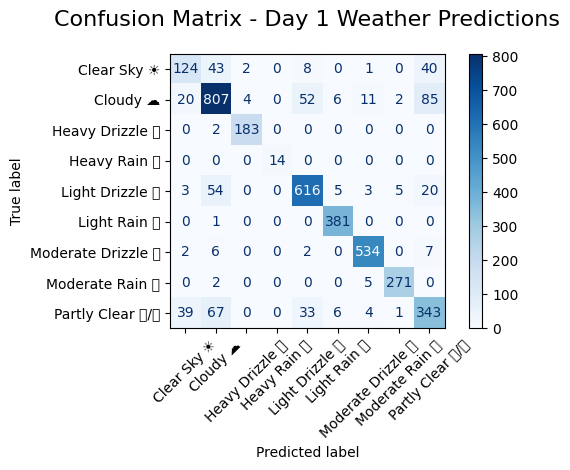


🎯 CLASS-TIER PERFORMANCE ANALYSIS:

MINORITY CLASSES:
----------------------------------------
  ✅ Moderate Drizzle 🌧       : P=0.957, R=0.969, F1=0.963, N=551.0
  ✅ Light Rain 🌦             : P=0.957, R=0.997, F1=0.977, N=382.0
  ✅ Moderate Rain 🌧          : P=0.971, R=0.975, F1=0.973, N=278.0
  ✅ Heavy Drizzle 🌧          : P=0.968, R=0.989, F1=0.979, N=185.0
  ✅ Heavy Rain 🌧             : P=1.000, R=1.000, F1=1.000, N=14.0

  📊 MINORITY AVERAGES:
     Precision: 0.9708
     Recall: 0.9861
     F1-Score: 0.9783

BALANCED CLASSES:
----------------------------------------
  ✅ Light Drizzle 🌦          : P=0.866, R=0.873, F1=0.869, N=706.0
  ✅ Clear Sky ☀️             : P=0.660, R=0.569, F1=0.611, N=218.0

  📊 BALANCED AVERAGES:
     Precision: 0.7630
     Recall: 0.7207
     F1-Score: 0.7401

MAJORITY CLASSES:
----------------------------------------
  ✅ Cloudy ☁️                : P=0.822, R=0.818, F1=0.820, N=987.0
  ✅ Partly Clear 🌤/⛅         : P=0.693, R=0.696, F1=0.694, N=493.0

  📊

In [3]:
def run_transformer_weather_forecasting(df, use_augmentation=True):
    """Run Time Series Transformer + rebalancing weather forecasting"""
    print("🌤️  TIME SERIES TRANSFORMER + REBALANCING Weather Forecasting")
    print("=" * 70)
    
    # Initialize Transformer model
    model = AutoformerTimeSeriesClassifier(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train Transformer model with rebalancing
    acc, daily_accs, history, y_true, y_pred = model.train_autoformer_model()
    
    print(f"\n🎯 FINAL TRANSFORMER RESULTS:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Best Day Accuracy: {max(daily_accs):.4f}")
    
    return model, acc, daily_accs, y_true, y_pred, history

# Usage:
transformer_model, acc, daily_accs, y_true, y_pred, history = run_transformer_weather_forecasting(df)